In [18]:

from glob import glob
import pandas as pd
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

#from tslearn.clustering import TimeSeriesKMeans
#from tslearn.preprocessing import TimeSeriesScalerMeanVariance

from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch

from scipy.spatial.distance import cdist

import numpy as np
import math

import rasterio as rio
import geopandas as gpd
from rasterio.plot import show
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from scipy.cluster.hierarchy import fcluster

daily_output = '/home/oisanchezp/Thesis/data/metadata/daily_gauges_SIATA_EPM/'

# 1. Obtén la lista de archivos diarios
daily_files = sorted(glob(daily_output + 'Daily_Est_*.csv'))

# 2. Extrae el número de estación desde el nombre de archivo
stations_with_paths = [
    (int(os.path.basename(file).split('_')[-1].split('.')[0]), file) 
    for file in daily_files
]

# 3. Ordena la lista por número de estación
stations_with_paths_sorted = sorted(stations_with_paths, key=lambda x: x[0])

# 4. Filtra las estaciones de SIATA (excluyendo las últimas 16, que asumes son EPM)
siata_stations_with_paths = stations_with_paths_sorted[:-16]

# 5. Carga y renombra los datos de cada estación
data_frames = []
station_numbers = []

for station_number, file in siata_stations_with_paths:
    # Lee el archivo CSV usando 'Fecha' como índice de tipo datetime
    station_data = pd.read_csv(file, index_col='Fecha', parse_dates=True)

    # Intenta renombrar la columna de precipitación como 'Est_{station_number}'
    if 'P' in station_data.columns:
        station_data.rename(columns={'P': f'Est_{station_number}'}, inplace=True)
    else:
        # Si no existe la columna 'P', busca alguna columna que contenga 'P' en su nombre
        precip_column = [col for col in station_data.columns if 'P' in col.upper()]
        if precip_column:
            station_data.rename(
                columns={precip_column[0]: f'Est_{station_number}'}, 
                inplace=True
            )
        else:
            print(f"Advertencia: No se encontró columna de precipitación en {file}")
            continue

    data_frames.append(station_data)
    station_numbers.append(station_number)

# 6. Concatena todos los DataFrames, uniendo por índice (outer join)
all_stations_df = pd.concat(data_frames, axis=1, join='outer')

# Dejar estaciones con 10 o más años de datos
min_hours = 10 * 365
# Filtra columnas (estaciones) que tengan al menos 'min_hours' datos válidos (no nulos)
all_stations_df_10y = all_stations_df.loc[:, all_stations_df.count() >= min_hours]

# Filtrar filas desde '2013-01-01' hasta el final de las series
all_stations_df_10y = all_stations_df_10y.loc['2013-01-01':]

# Mostrar la cantidad de datos faltantes por estación
missing_values = all_stations_df_10y.isna().sum()
total_days = len(all_stations_df_10y)
missing_percentage = (missing_values / total_days) * 100


# 1. Creamos el DataFrame con ambas series
df_missing = pd.DataFrame({
    'Datos_faltantes': missing_values,
    'Porcentaje_NaN': missing_percentage
})

# 2. Redondear el porcentaje a 2 decimales
df_missing['Porcentaje_NaN'] = df_missing['Porcentaje_NaN'].round(2)

print()

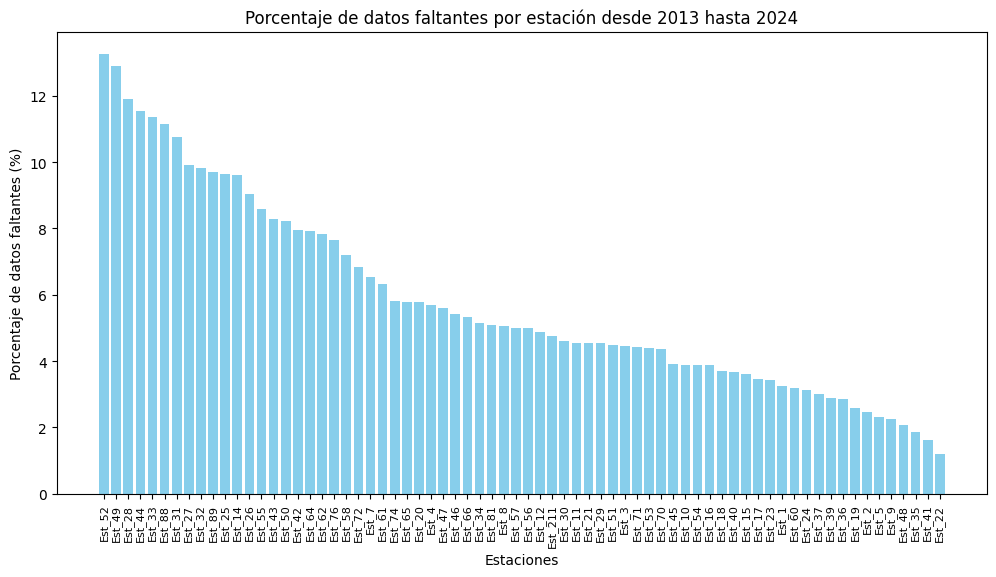

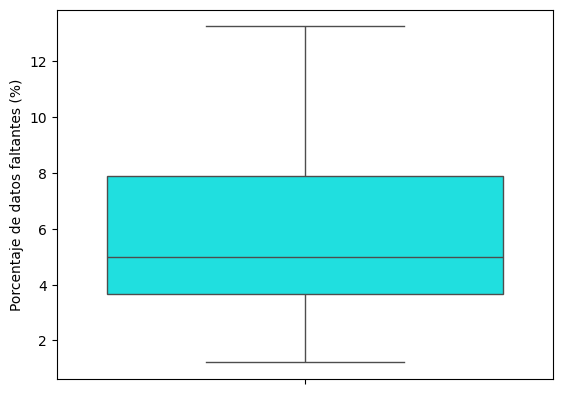

In [19]:
# Hacer un gráfico de barras con los datos faltantes
df_missing_sorted = df_missing.sort_values(by='Porcentaje_NaN', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(df_missing_sorted.index, df_missing_sorted['Porcentaje_NaN'], color='skyblue')
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Porcentaje de datos faltantes (%)")
plt.xlabel("Estaciones")
plt.title("Porcentaje de datos faltantes por estación desde 2013 hasta 2024")
plt.show()


# Hacer un histograma de los porcentajes de datos faltantes

# plt.figure(figsize=(8, 6))
# plt.hist(df_missing['Porcentaje_NaN'], bins=20, color='blue', edgecolor='black', alpha=0.7)
# plt.xlabel("Porcentaje de datos faltantes (%)")
# plt.ylabel("Número de estaciones")
# plt.title("Distribución de estaciones según porcentaje de datos faltantes")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.show()


# Hacer un boxplot de los porcentajes de datos faltantes
sns.boxplot(y=df_missing['Porcentaje_NaN'], color="cyan")
plt.ylabel("Porcentaje de datos faltantes (%)")
plt.show()

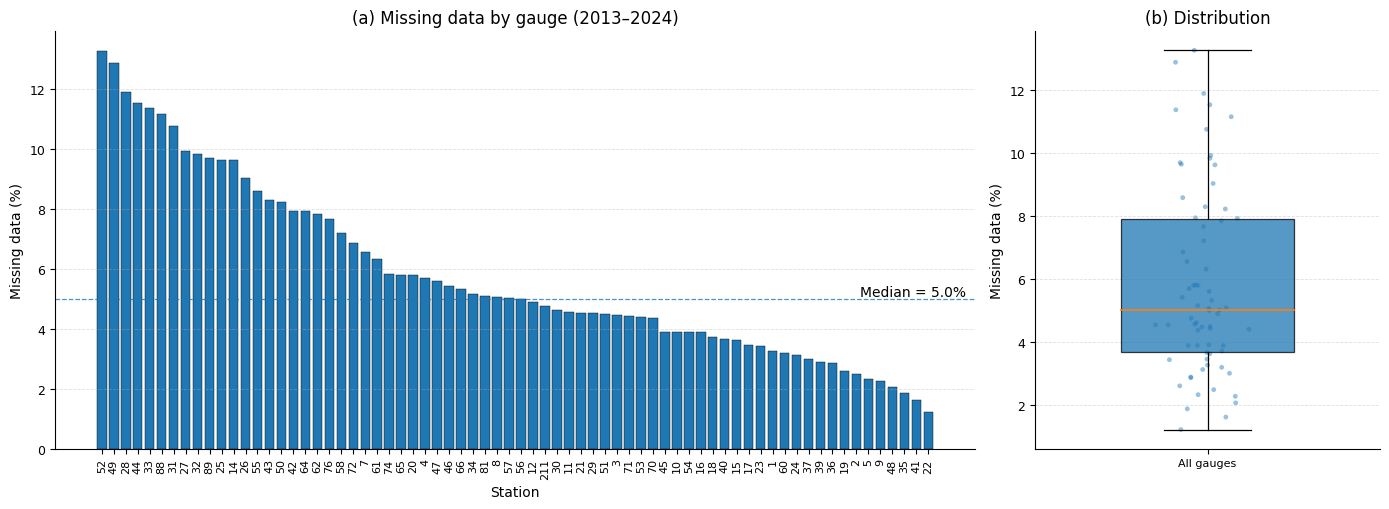

In [1]:
import os
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# 1) Load + build station table
# -----------------------------
daily_output = "/home/oisanchezp/Thesis/data/metadata/daily_gauges_SIATA_EPM/"
daily_files = sorted(glob(os.path.join(daily_output, "Daily_Est_*.csv")))

stations_with_paths = [
    (int(os.path.basename(fp).split("_")[-1].split(".")[0]), fp)
    for fp in daily_files
]
stations_with_paths_sorted = sorted(stations_with_paths, key=lambda x: x[0])

# SIATA only (exclude last 16 assumed EPM)
siata_stations_with_paths = stations_with_paths_sorted[:-16]

data_frames = []
station_numbers = []

for station_number, fp in siata_stations_with_paths:
    df = pd.read_csv(fp, index_col="Fecha", parse_dates=True)

    # Identify precipitation column
    if "P" in df.columns:
        precip_col = "P"
    else:
        candidates = [c for c in df.columns if "P" in str(c).upper()]
        if not candidates:
            print(f"Warning: No precipitation column found in {fp}")
            continue
        precip_col = candidates[0]

    df = df[[precip_col]].rename(columns={precip_col: f"Est_{station_number}"})
    data_frames.append(df)
    station_numbers.append(station_number)

all_stations_df = pd.concat(data_frames, axis=1, join="outer")

# Keep stations with >= 10 years of DAILY data (roughly; ignores leap years)
min_days = 10 * 365
all_stations_df_10y = all_stations_df.loc[:, all_stations_df.count() >= min_days]

# Analysis window
all_stations_df_10y = all_stations_df_10y.loc["2013-01-01":]

# -----------------------------
# 2) Missingness diagnostics
# -----------------------------
missing_values = all_stations_df_10y.isna().sum()
total_days = len(all_stations_df_10y)
missing_percentage = (missing_values / total_days) * 100

df_missing = pd.DataFrame(
    {
        "Missing_days": missing_values.astype(int),
        "Missing_pct": missing_percentage.round(2),
    }
)

df_missing_sorted = df_missing.sort_values("Missing_pct", ascending=False)

# -----------------------------
# 3) Paper-style figure (2 panels)
# -----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5.2),
    gridspec_kw={"width_ratios": [3.2, 1.2]}
)

# --- (a) Bar chart: missing percentage by station (sorted) ---
x = np.arange(len(df_missing_sorted))
y = df_missing_sorted["Missing_pct"].to_numpy()

ax1.bar(x, y, edgecolor="black", linewidth=0.3)
ax1.set_ylabel("Missing data (%)")
ax1.set_xlabel("Station")
ax1.set_title("(a) Missing data by gauge (2013–2024)")

# --- reemplaza SOLO este bloque dentro del panel (a) ---

labels = [s.replace("Est_", "") for s in df_missing_sorted.index.astype(str).to_list()]

ax1.set_xticks(x)  # todos
ax1.set_xticklabels(labels, rotation=90, va="top")


ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4)

# Optional: highlight median missingness
med = np.nanmedian(y)
ax1.axhline(med, linestyle="--", linewidth=0.9, alpha=0.8)
ax1.text(
    0.99, med,
    f"Median = {med:.1f}%",
    transform=ax1.get_yaxis_transform(),
    ha="right", va="bottom"
)

# --- (b) Boxplot: distribution of missing percentage ---
vals = df_missing["Missing_pct"].to_numpy()

bp = ax2.boxplot(
    vals,
    vert=True,
    widths=0.5,
    showfliers=True,
    patch_artist=True,
    boxprops=dict(linewidth=0.9),
    medianprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=0.9),
    capprops=dict(linewidth=0.9),
)

# Fill box (simple, print-friendly)
bp["boxes"][0].set_alpha(0.75)

# Add jittered points for transparency of sample size
rng = np.random.default_rng(7)
jitter = 0.06 * rng.standard_normal(size=len(vals))
ax2.scatter(
    np.ones_like(vals) + jitter, vals,
    s=12, alpha=0.45, edgecolor="none"
)

ax2.set_xticks([1])
ax2.set_xticklabels(["All gauges"])
ax2.set_ylabel("Missing data (%)")
ax2.set_title("(b) Distribution")

ax2.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4)

#fig.suptitle("Data availability of SIATA rain gauges", y=1.02)
fig.tight_layout()

#plt.savefig("/home/oisanchezp/Thesis/results/02_Chapter/fig02.png", dpi=100, bbox_inches="tight")
plt.show()


## **AÑADIR UNA COLUMNA DE PORCENTAJE DE DATOS FALTANTES AL GEOJSON PLUVIOS**

In [2]:
import geopandas as gpd

gdf_pluvios = gpd.read_file("/home/oisanchezp/Thesis/data/metadata/pluvios.geojson")
print(gdf_pluvios.columns.tolist())
print(gdf_pluvios.head(3))
print("CRS:", gdf_pluvios.crs)

['Codigo', 'NombreEstacion', 'FechaInstalacion', 'Estado', 'Longitude', 'Latitude', 'geometry']
   Codigo                      NombreEstacion FechaInstalacion Estado  \
0      27  Centro de Salud San Javier La Loma       2010-01-25      I   
1      29                 Escuela Marina Orth       2010-01-25      A   
2      10           Escuela Rural El Boqueron       2010-01-01      A   

   Longitude  Latitude                   geometry  
0 -75.631123  6.271891  POINT (-75.63112 6.27189)  
1 -75.643773  6.232313  POINT (-75.64377 6.23231)  
2 -75.657627  6.315334  POINT (-75.65763 6.31533)  
CRS: EPSG:4326


In [5]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
from typing import Union

def add_missing_pct_to_geojson(
    geojson_in,         # str o Path
    df_missing,         # pd.DataFrame
    geojson_out,        # str o Path
    id_col="codigo",
    station_prefix="Est_",
):
    """
    Agrega el porcentaje de datos faltantes a un GeoJSON de pluviómetros.

    Parameters
    ----------
    geojson_in : ruta al GeoJSON original con la geometría de las estaciones.
    df_missing : DataFrame indexado por nombres tipo 'Est_<id>' con columna
                 'Missing_pct' (en %).
    geojson_out : ruta del GeoJSON de salida.
    id_col : nombre de la columna en el GeoJSON con el código de la estación.
    station_prefix : prefijo usado en el índice de df_missing (e.g., 'Est_').

    Returns
    -------
    GeoDataFrame con las columnas originales + 'missing_pct' + 'missing_days'.
    """
    # 1) Cargar geometrías
    gdf = gpd.read_file(geojson_in)

    if id_col not in gdf.columns:
        raise KeyError(
            f"La columna '{id_col}' no existe en el GeoJSON. "
            f"Columnas disponibles: {gdf.columns.tolist()}"
        )

    # 2) Construir tabla auxiliar con id numérico
    df_aux = df_missing.copy()
    df_aux.index = df_aux.index.astype(str).str.replace(
        station_prefix, "", regex=False
    )
    df_aux.index = pd.to_numeric(df_aux.index, errors="coerce").astype("Int64")
    df_aux = df_aux.rename(
        columns={"Missing_pct": "missing_pct", "Missing_days": "missing_days"}
    )
    df_aux = df_aux.reset_index().rename(columns={"index": id_col})

    # 3) Asegurar tipo compatible en ambos lados
    gdf[id_col] = pd.to_numeric(gdf[id_col], errors="coerce").astype("Int64")

    # 4) Merge y diagnóstico
    gdf_out = gdf.merge(df_aux, on=id_col, how="left")

    n_total = len(gdf_out)
    n_nan = gdf_out["missing_pct"].isna().sum()
    n_extra = len(df_aux) - (n_total - n_nan)
    print(f"Estaciones en GeoJSON: {n_total}")
    print(f"Estaciones SIN match (sin missing_pct): {n_nan}")
    print(f"Estaciones en df_missing sin geometría: {max(n_extra, 0)}")

    # 5) Conservar CRS y guardar
    if gdf_out.crs is None:
        print("Aviso: el GeoJSON no tenía CRS. Asignando EPSG:4326 por defecto.")
        gdf_out.set_crs(epsg=4326, inplace=True)

    Path(geojson_out).parent.mkdir(parents=True, exist_ok=True)
    gdf_out.to_file(geojson_out, driver="GeoJSON")
    print(f"GeoJSON guardado en: {geojson_out}")

    return gdf_out


# --- Uso ---
gdf_pluvios_missing = add_missing_pct_to_geojson(
    geojson_in="/home/oisanchezp/Thesis/data/metadata/pluvios.geojson",
    df_missing=df_missing,
    geojson_out="/home/oisanchezp/Thesis/data/metadata/pluvios_missing.geojson",
    id_col="Codigo",          # <-- AJUSTA si tu columna se llama distinto
    station_prefix="Est_",
)

gdf_pluvios_missing[["Codigo", "missing_pct", "missing_days", "geometry"]].head()

Estaciones en GeoJSON: 70
Estaciones SIN match (sin missing_pct): 6
Estaciones en df_missing sin geometría: 6
GeoJSON guardado en: /home/oisanchezp/Thesis/data/metadata/pluvios_missing.geojson


,Codigo,missing_pct,missing_days,geometry
0,27,9.92,420.0,POINT (-75.63112 6.27189)
1,29,4.54,192.0,POINT (-75.64377 6.23231)
2,10,3.88,164.0,POINT (-75.65763 6.31533)
3,5,2.32,98.0,POINT (-75.49214 6.20621)
4,25,9.64,408.0,POINT (-75.66688 6.23977)
